In [3]:
import numpy as np
import pandas as pd


In [5]:
df = pd.read_csv('homeprices.csv')
df.head()

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000


- in here there are Some values in the town so model only know the numerical values so we have to address the above issue
- So one solution is we can assign and number for the value like the below
- 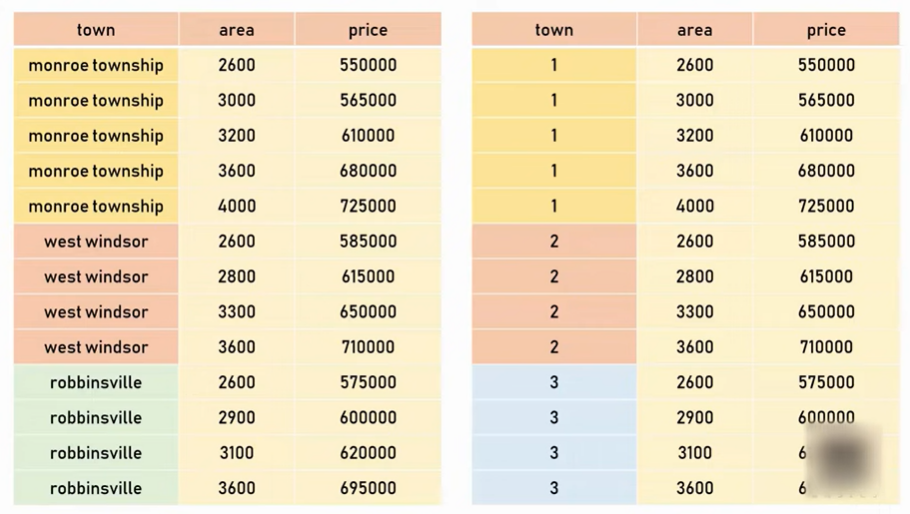
- The problem of the above one is the model will think like the below
- 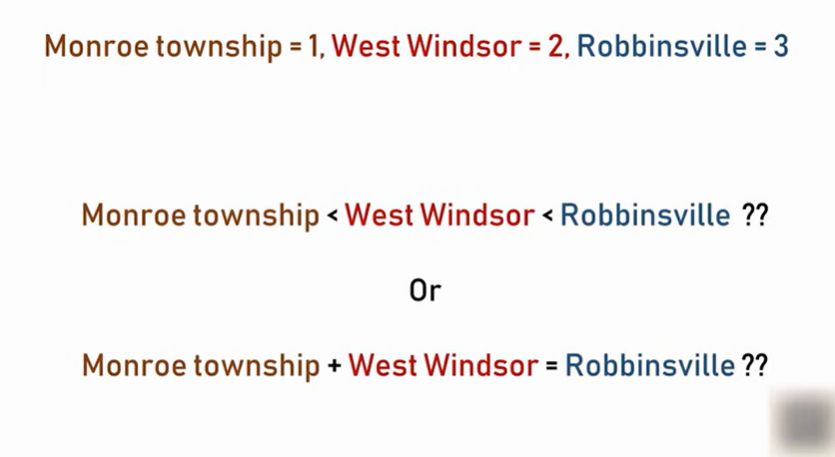
- So the Solution is "One Hot encoding " . 

## Using pandas library 

- using the pandas library we can create dummy data in categorical data
- 

In [7]:
dummies = pd.get_dummies(df.town)
dummies

,monroe township,robinsville,west windsor
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
5,False,False,True
6,False,False,True
7,False,False,True
8,False,False,True
9,False,True,False


In [9]:
merged = pd.concat([df,dummies],axis = 'columns')
merged

,town,area,price,monroe township,robinsville,west windsor
0,monroe township,2600,550000,True,False,False
1,monroe township,3000,565000,True,False,False
2,monroe township,3200,610000,True,False,False
3,monroe township,3600,680000,True,False,False
4,monroe township,4000,725000,True,False,False
5,west windsor,2600,585000,False,False,True
6,west windsor,2800,615000,False,False,True
7,west windsor,3300,650000,False,False,True
8,west windsor,3600,710000,False,False,True
9,robinsville,2600,575000,False,True,False


In [11]:
final  = merged.drop(['town'],axis='columns')
final

,area,price,monroe township,robinsville,west windsor
0,2600,550000,True,False,False
1,3000,565000,True,False,False
2,3200,610000,True,False,False
3,3600,680000,True,False,False
4,4000,725000,True,False,False
5,2600,585000,False,False,True
6,2800,615000,False,False,True
7,3300,650000,False,False,True
8,3600,710000,False,False,True
9,2600,575000,False,True,False


- in here we can drop a one column from dummy columns because sklearn will know what columns they want and do not want

In [14]:
final = final.drop(['west windsor'],axis='columns')
final.head()

,area,price,monroe township,robinsville
0,2600,550000,True,False
1,3000,565000,True,False
2,3200,610000,True,False
3,3600,680000,True,False
4,4000,725000,True,False


In [16]:
x = final.drop(['price'],axis='columns')
x.head()

,area,monroe township,robinsville
0,2600,True,False
1,3000,True,False
2,3200,True,False
3,3600,True,False
4,4000,True,False


In [18]:
y = final.price
y.head()

0    550000
1    565000
2    610000
3    680000
4    725000
Name: price, dtype: int64

In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [26]:
model.fit(x,y)

LinearRegression()

In [28]:
model.predict([[3400,0,0]])

C:\Users\sdara\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([681241.66845839])

In [30]:
model.predict([[2800,0,1]])

C:\Users\sdara\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([590775.63964739])

In [32]:
model.score(x,y)

0.9573929037221871

## Using the SKlearn onehot encoding 

In [34]:
df = pd.read_csv('homeprices.csv')
df.head()



,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000


In [109]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

In [113]:
encoded_town =  encoder.fit_transform(df[['town']])
encoded_town

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [121]:
encoded_df =  pd.DataFrame(encoded_town,columns=encoder.get_feature_names_out(['town']))
df = pd.concat([df.drop(columns=['town']), encoded_df], axis=1)

In [123]:
df.head()

,area,price,town_0,town_1,town_2
0,2600,550000,1.0,0.0,0.0
1,3000,565000,1.0,0.0,0.0
2,3200,610000,1.0,0.0,0.0
3,3600,680000,1.0,0.0,0.0
4,4000,725000,1.0,0.0,0.0


In [129]:
X = df.drop(columns=['price'])  # All columns except 'price'
y = df['price']                 # Target column (price)

In [131]:
# Initialize Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X, y)

print("Model training complete.")


Model training complete.


In [133]:
model.score(X,y)

0.9573929037221873

In [145]:

# Predict the price
predicted_price = model.predict([[1,0,0,2800]])
predicted_price

C:\Users\sdara\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([50950573.57557531])